# Базовое моделирование на подготовленном датасете

## Цель этапа

Этот ноутбук добавляет воспроизводимый базовый эксперимент после первичного анализа: регрессию на `final_dataset_for_modeling.csv`. Цель этапа — проверить, есть ли в подготовленных признаках первичный предсказательный сигнал для интенсивности изменения береговой бровки.

Это не финальная нейросетевая часть и не причинная экологическая интерпретация. Базовый эксперимент нужен как точка отсчёта перед сравнением более сложных статистических и нейросетевых методов.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from src.analysis.baseline_modeling import (
    TARGET_DECISION_NOTE,
    build_feature_frame,
    choose_target,
    run_baseline_modeling,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)

project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent
processed_dir = project_root / 'data' / 'processed'
reports_dir = project_root / 'reports'


## Загрузка данных

Основной вход — `data/processed/final_dataset_for_modeling.csv`. Это компактный производный датасет, собранный из безопасного аналитического слоя первого этапа.

Ноутбук запускает тот же воспроизводимый модуль, что и команда `python -m src.analysis.baseline_modeling`, а затем читает сохранённые таблицы и графики из `reports/`.

In [2]:
outputs = run_baseline_modeling(verbose=False)
pd.DataFrame({
    'показатель': [
        'целевая переменная',
        'число строк',
        'число признаков до кодирования категорий',
        'модель с минимальной MAE на тестовой выборке',
        'MAE этой модели',
        'RMSE этой модели',
        'R2 этой модели',
    ],
    'значение': [
        outputs['target'],
        outputs['n_rows'],
        outputs['n_features'],
        outputs['best_model'],
        round(outputs['best_test_mae'], 4),
        round(outputs['best_test_rmse'], 4),
        round(outputs['best_test_r2'], 4),
    ],
})

,показатель,значение
0,целевая переменная,retreat_rate_abs_m_per_year
1,число строк,575
2,число признаков до кодирования категорий,23
3,модель с минимальной MAE на тестовой выборке,HistGradientBoostingRegressor
4,MAE этой модели,1.7842
5,RMSE этой модели,6.7759
6,R2 этой модели,0.3588


In [3]:
data = pd.read_csv(processed_dir / 'final_dataset_for_modeling.csv')
metrics = pd.read_csv(reports_dir / 'tables' / 'baseline_modeling_metrics.csv')
group_metrics = pd.read_csv(reports_dir / 'tables' / 'baseline_group_validation_metrics.csv')
feature_importance = pd.read_csv(reports_dir / 'tables' / 'baseline_feature_importance.csv')
worst_predictions = pd.read_csv(reports_dir / 'tables' / 'baseline_worst_predictions.csv')

target = choose_target(data)
X, y, metadata, numeric_features, categorical_features, excluded_columns = build_feature_frame(data, target)

pd.DataFrame({
    'показатель': [
        'строк в исходном производном датасете',
        'строк с непустой целевой переменной',
        'числовых признаков',
        'категориальных признаков',
        'всего признаков до кодирования категорий',
    ],
    'значение': [len(data), len(y), len(numeric_features), len(categorical_features), X.shape[1]],
})

,показатель,значение
0,строк в исходном производном датасете,575
1,строк с непустой целевой переменной,575
2,числовых признаков,15
3,категориальных признаков,8
4,всего признаков до кодирования категорий,23


## Целевая переменная и признаки

Целевая переменная выбирается в модуле явно и воспроизводимо: `retreat_rate_abs_m_per_year`. Это беззнаковая интенсивность изменения береговой бровки в м/год. Она выбрана потому, что нормирована на длительность интервала и не требует автоматической трактовки знака смещения.

Из признаков исключаются сама целевая переменная, другие прямые метрики береговой бровки (`retreat_m`, `retreat_rate_m_per_year`, `retreat_abs_m`), длительность интервала как компонент формулы целевой переменной, идентификаторы, даты в исходном текстовом виде и служебные тексты проверки качества. Даты используются только в виде осторожного признака `interval_mid_year`, который описывает положение интервала во времени.

In [4]:
print(TARGET_DECISION_NOTE)
display(y.describe().rename('target_summary').to_frame())

feature_table = pd.DataFrame({
    'feature_name': numeric_features + categorical_features,
    'feature_type': ['числовой'] * len(numeric_features) + ['категориальный'] * len(categorical_features),
})
feature_table

Выбрана целевая переменная `retreat_rate_abs_m_per_year`: это беззнаковая интенсивность изменения береговой бровки, нормированная на длительность интервала. Такая целевая переменная безопаснее для базовой регрессии, чем знаковые метрики, потому что знак смещения требует отдельной доменной интерпретации.


,target_summary
count,575.000000
mean,2.394433
std,5.535955
min,0.000000
25%,0.185230
50%,1.040466
75%,3.177630
max,73.050000


,feature_name,feature_type
0,shore_orientation_deg,числовой
1,n_water_obs,числовой
2,coverage_water,числовой
3,mean_water_level_mean_annual_m_abs,числовой
4,max_water_level_mean_annual_m_abs,числовой
5,min_water_level_mean_annual_m_abs,числовой
6,range_water_level_mean_annual_m_abs,числовой
7,mean_water_level_max_annual_m_abs,числовой
8,max_water_level_max_annual_m_abs,числовой
9,min_water_level_max_annual_m_abs,числовой


## Методика проверки качества

Используется фиксированный `RANDOM_STATE = 42`. Основная таблица сохраняет случайное разбиение на обучающую и тестовую выборки в пропорции 80/20. Кросс-валидация считается только на обучающей выборке.

Дополнительно считается групповая проверка с разделением по профилям, если доступна колонка `profile_id`. В этом случае тестовая выборка содержит профили, которые не попадали в обучение. Если `profile_id` недоступен, модуль пробует `site_id`; если групповых колонок нет, это явно записывается в отчёте.

Предобработка находится внутри независимой цепочки `sklearn Pipeline` для каждой модели: числовые признаки заполняются медианой и масштабируются, категориальные признаки заполняются наиболее частым значением и кодируются. Это снижает риск утечки информации из тестовой выборки.

## Сравнение моделей

Сравниваются пять подходов:

- `DummyRegressor` как нижняя точка отсчёта;
- `Ridge` как интерпретируемая линейная модель;
- `RandomForestRegressor` как нелинейная ансамблевая модель;
- `HistGradientBoostingRegressor` как более сильная табличная базовая модель;
- `MLPRegressor` как первый простой нейросетевой ориентир.

## Первый нейросетевой ориентир

`MLPRegressor` — простая полносвязная нейросетевая модель для регрессии из `scikit-learn`. Она добавлена не как финальная нейросетевая часть, а как первый ориентир: можно сравнить, даёт ли нейросетевой подход выигрыш относительно более простых и ансамблевых моделей.

Модель запускается с небольшой архитектурой и без глубокого подбора параметров. Если она хуже простых моделей, это не провал, а возможный признак малого объёма данных, шума или необходимости более аккуратной настройки. Если она лучше, это всё равно не доказывает причинную связь, а только показывает улучшение прогноза по выбранным метрикам.

In [5]:
metrics_display = metrics[[
    'validation_scheme',
    'model',
    'cv_mae_mean',
    'cv_rmse_mean',
    'cv_r2_mean',
    'test_mae',
    'test_rmse',
    'test_r2',
    'is_best_by_test_mae',
]].copy()
for column in ['cv_mae_mean', 'cv_rmse_mean', 'cv_r2_mean', 'test_mae', 'test_rmse', 'test_r2']:
    metrics_display[column] = metrics_display[column].round(4)
metrics_display

,validation_scheme,model,cv_mae_mean,cv_rmse_mean,cv_r2_mean,test_mae,test_rmse,test_r2,is_best_by_test_mae
0,случайное разбиение на обучение и тест,HistGradientBoostingRegressor,1.4450,3.6215,0.0253,1.7842,6.7759,0.3588,True
1,случайное разбиение на обучение и тест,RandomForestRegressor,1.3489,3.4472,0.2457,1.9564,7.2803,0.2597,False
2,случайное разбиение на обучение и тест,Ridge,1.6476,3.6393,0.1606,2.0760,7.6937,0.1733,False
3,случайное разбиение на обучение и тест,MLPRegressor,1.4464,3.5968,0.2186,2.1146,8.0330,0.0988,False
4,случайное разбиение на обучение и тест,DummyRegressor_median,1.9986,4.2321,-0.1006,2.4483,8.6076,-0.0348,False


## График сравнения моделей

На графике ниже MAE и RMSE показывают ошибку в единицах целевой переменной, то есть в м/год. R2 показывает, насколько модель лучше или хуже простого прогноза средним значением на тестовой выборке.

Формулировка «лучшая модель» здесь означает только «лучшая по MAE на тестовой выборке при данном случайном разбиении». Кросс-валидация и групповая проверка могут давать другую картину, поэтому базовый эксперимент следует читать как первичную оценку предсказательного сигнала, а не как финальный вывод.

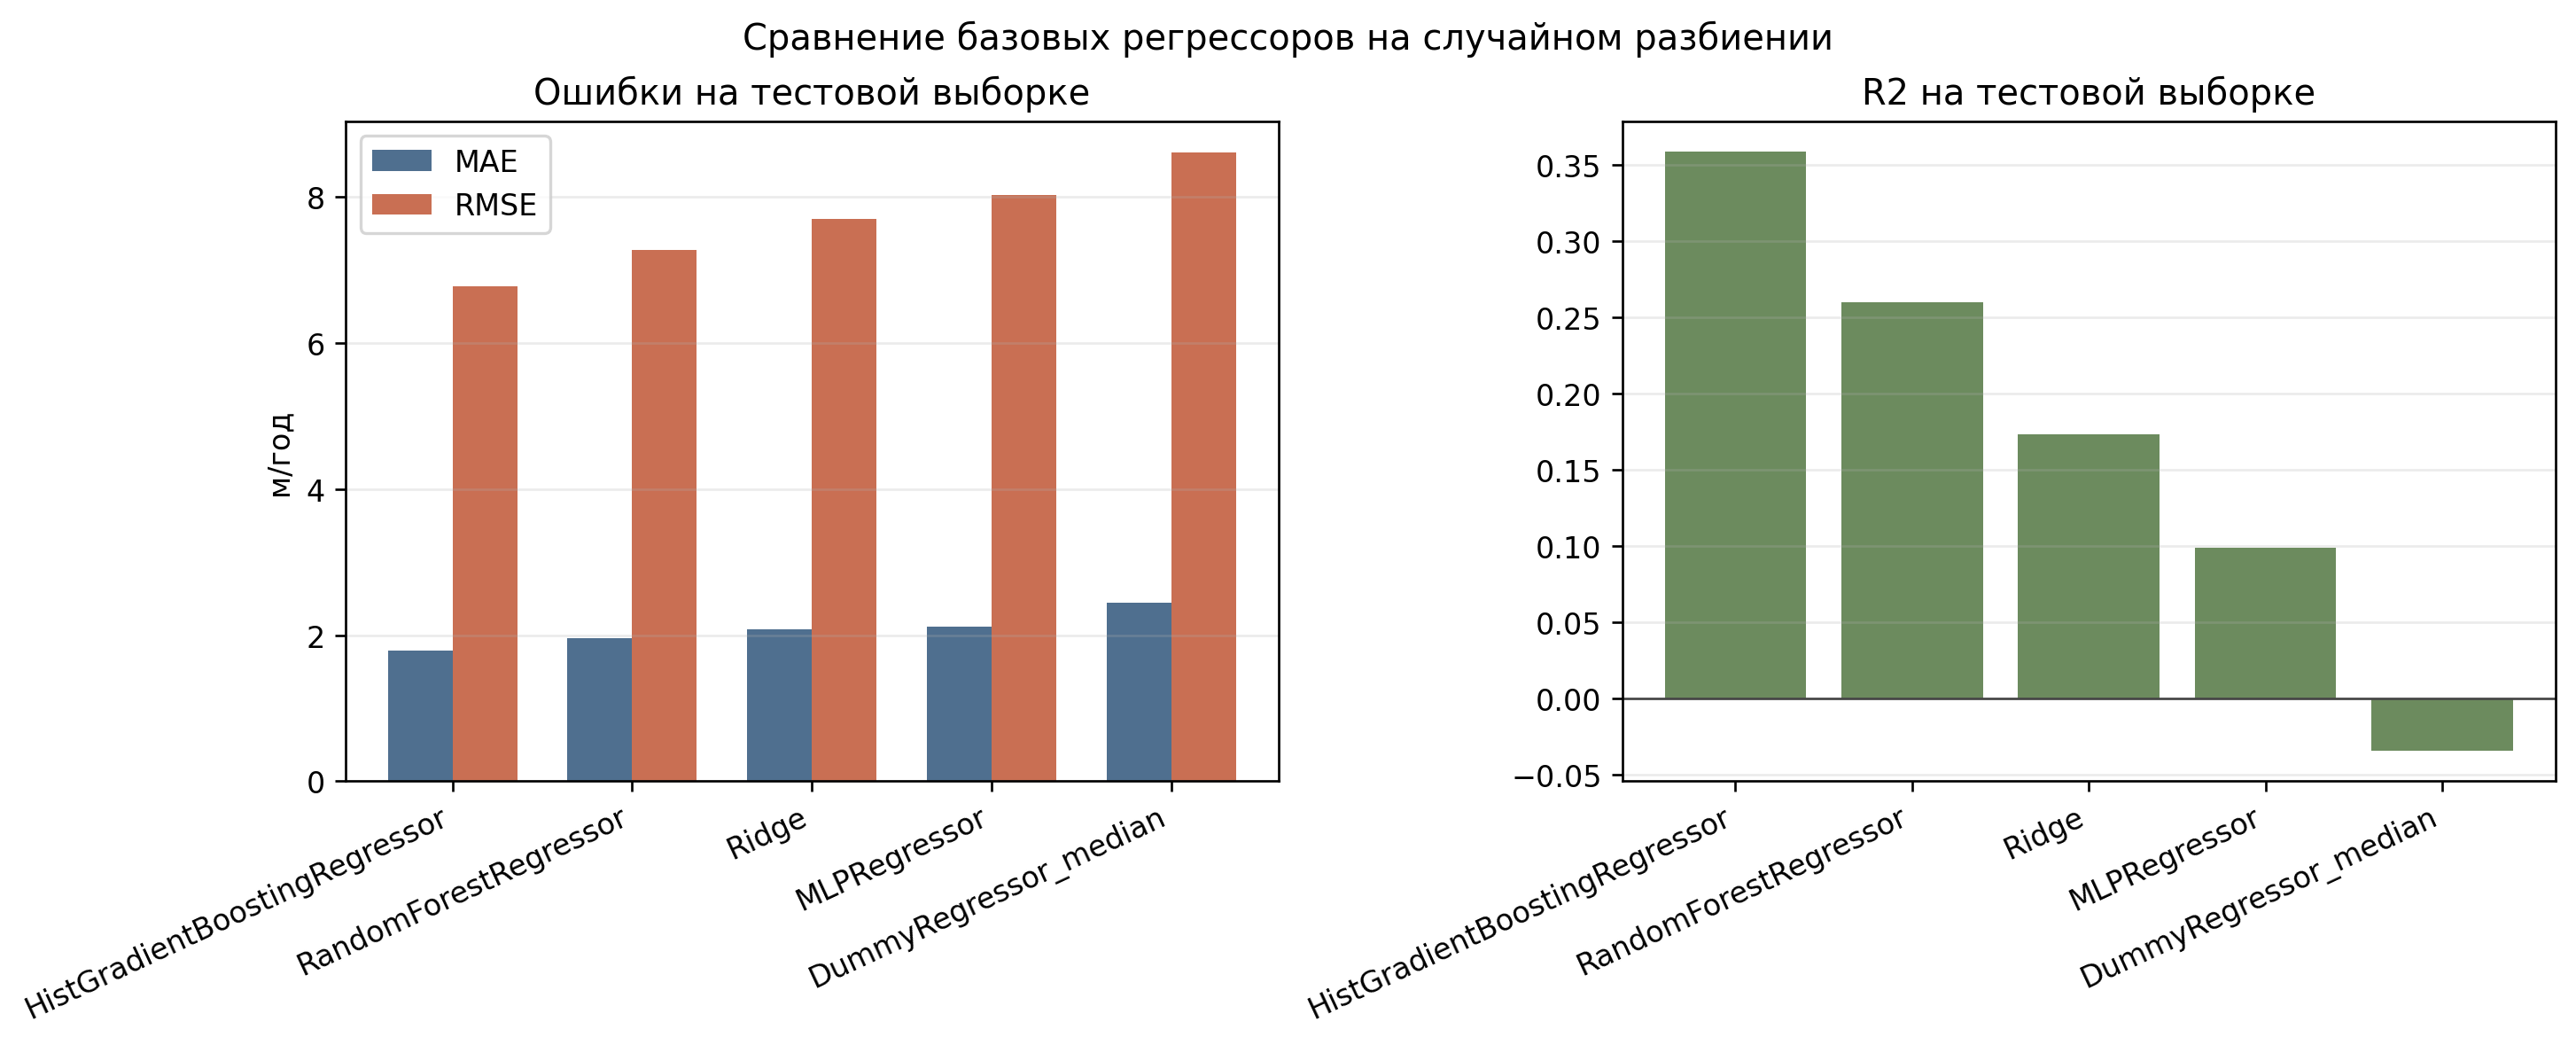

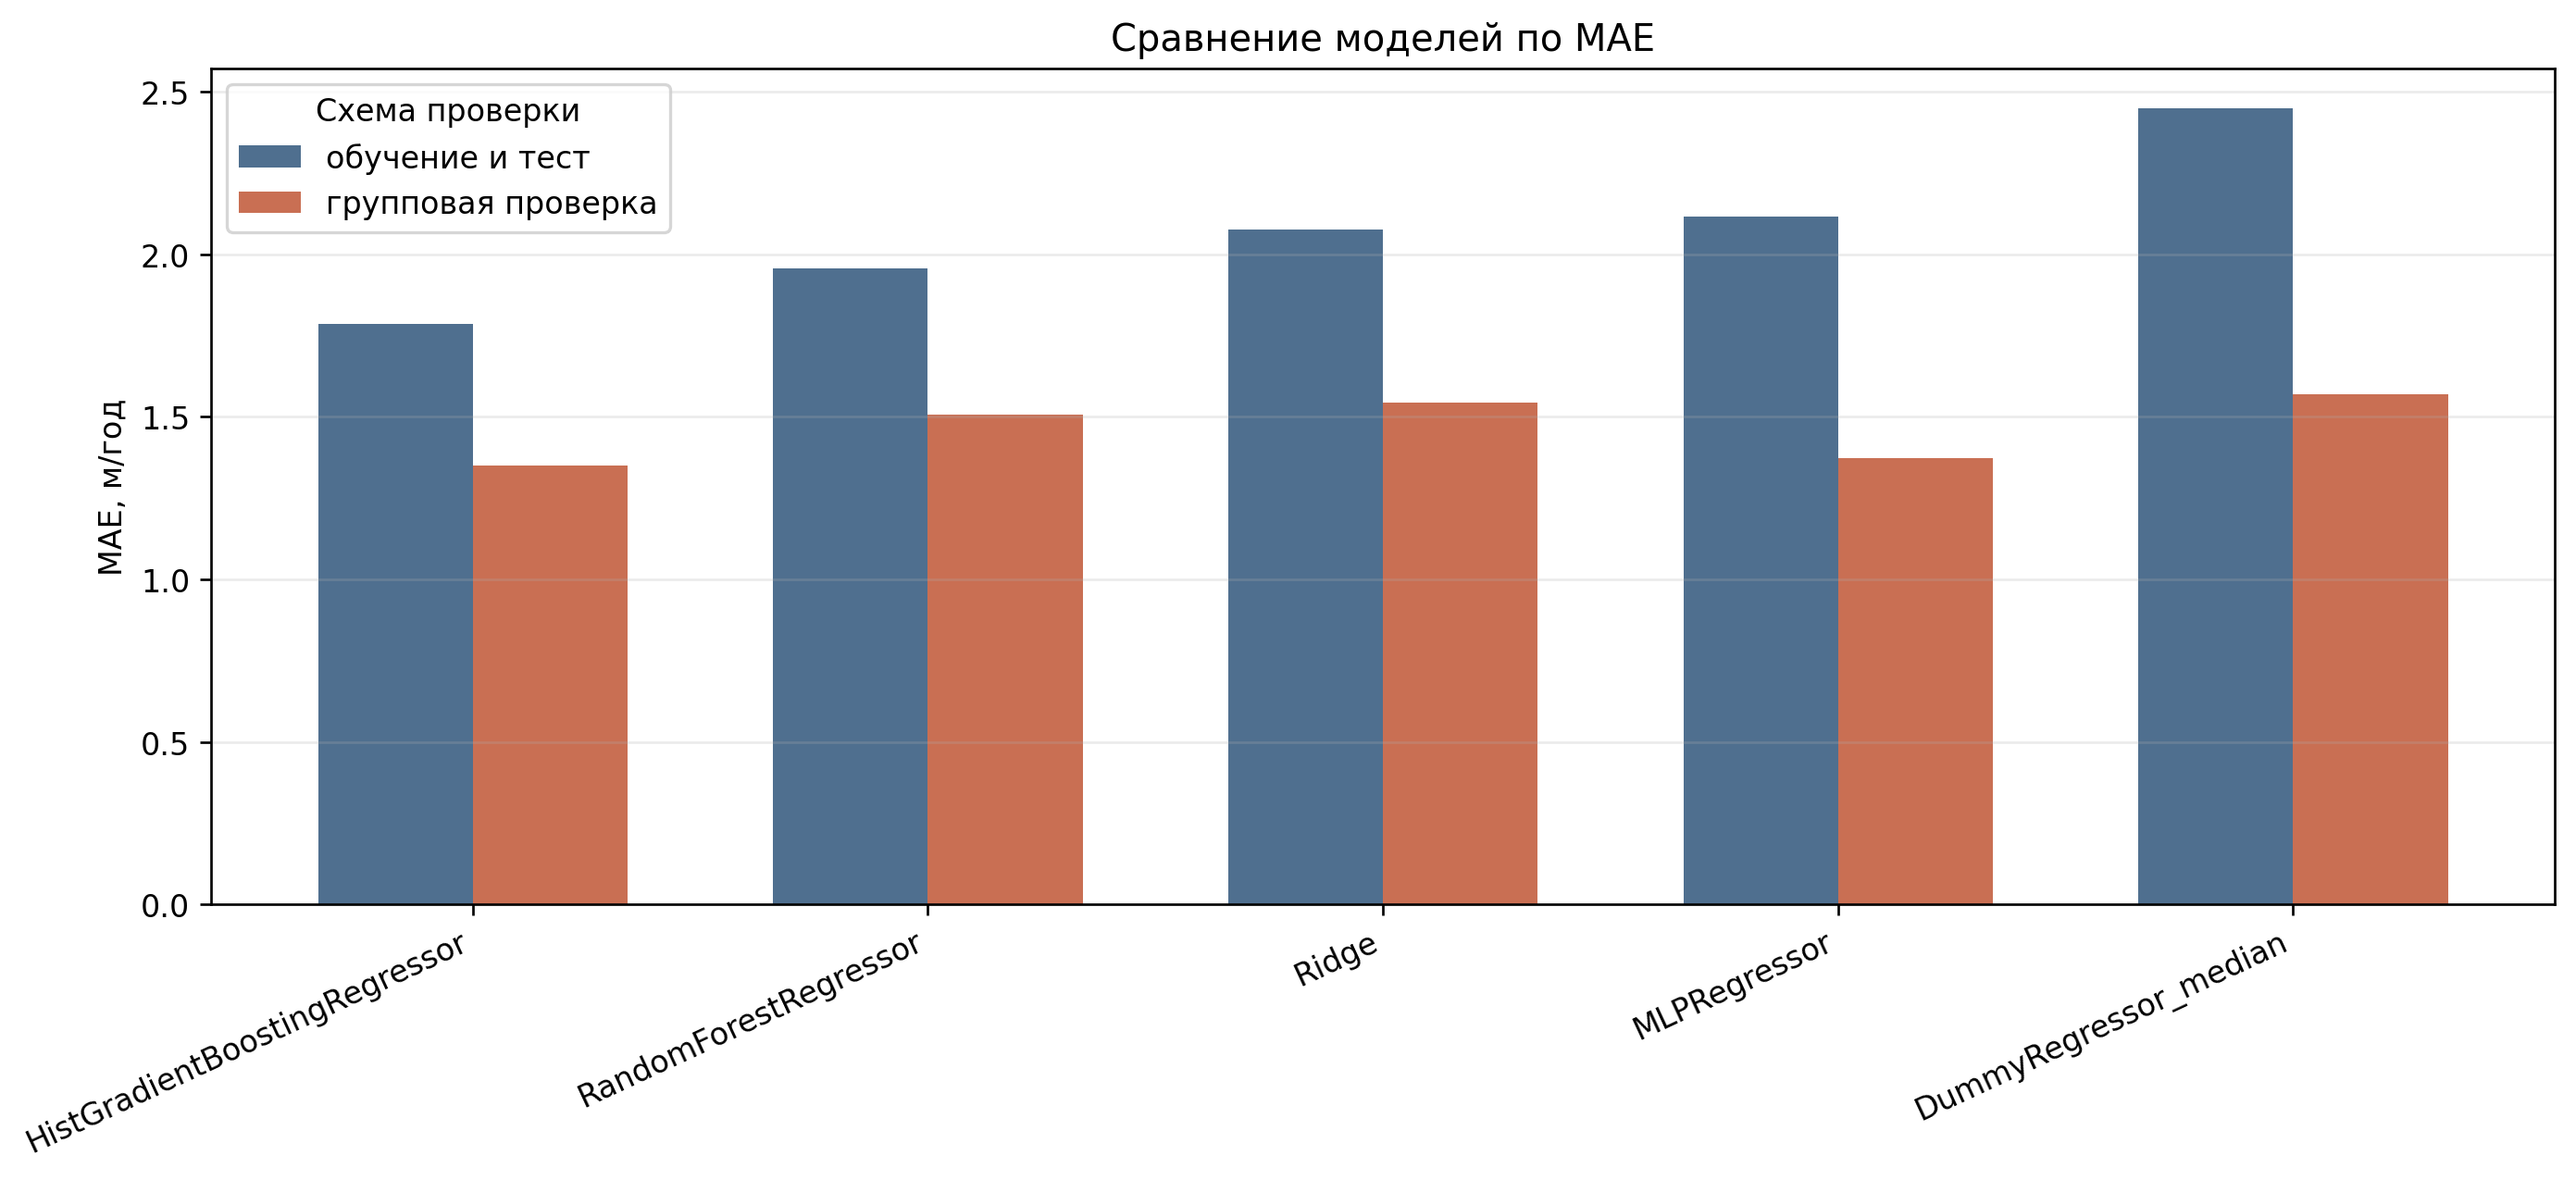

In [6]:
display(Image(filename=str(reports_dir / 'figures' / 'baseline_modeling_metrics.png')))
display(Image(filename=str(reports_dir / 'figures' / '03_model_comparison_mae.png')))

## Групповая проверка с разделением по профилям

Случайное разбиение может распределить интервалы одних и тех же профилей между обучающей и тестовой выборками. Поэтому отдельно сохранена групповая проверка с разделением по `profile_id`: тестовая выборка содержит профили, которые не использовались при обучении.

Эта таблица не заменяет случайное разбиение, а показывает более строгую проверку обобщения. Отрицательный R2 — плохой сигнал для обобщающей способности модели: на такой проверке модель может быть хуже простой опоры, даже если MAE выглядит приемлемо.

In [7]:
group_display = group_metrics.copy()
for column in ['MAE', 'RMSE', 'R2']:
    group_display[column] = group_display[column].round(4)
group_display

,model,group_column,n_groups,n_train,n_test,MAE,RMSE,R2
0,HistGradientBoostingRegressor,profile_id,28,457,118,1.3498,2.5409,-0.2670
1,MLPRegressor,profile_id,28,457,118,1.3736,2.0069,0.2097
2,RandomForestRegressor,profile_id,28,457,118,1.5053,3.4493,-1.3348
3,Ridge,profile_id,28,457,118,1.5428,2.1504,0.0926
4,DummyRegressor_median,profile_id,28,457,118,1.5687,2.4092,-0.1390


## Анализ ошибок прогноза

Для модели, лучшей по MAE на тестовой выборке при данном случайном разбиении, сохранены наблюдения с наибольшими ошибками прогноза. В текущем прогоне разрыв между MAE и RMSE действительно связан с несколькими крупными промахами: первые строки `baseline_worst_predictions.csv` имеют абсолютные ошибки порядка десятков м/год.

Это не повод удалять строки автоматически. Таблица нужна для ручной проверки: какие интервалы дают наибольший вклад в ошибку и связаны ли они с особенностями исходных наблюдений.

In [8]:
worst_predictions.head(15)

,rank,interval_id,site_id,profile_id,date_start,date_end,y_true,y_pred,signed_error,abs_error
0,1,novonikolskoe_profile_51_1959-12-11_1960-10-21,novonikolskoe,novonikolskoe_profile_51,1959-12-11,1960-10-21,73.050000,22.193655,-50.856345,50.856345
1,2,berezhnovka_profile_62_2000-07-13_2001-07-15,berezhnovka,berezhnovka_profile_62,2000-07-13,2001-07-15,54.501103,5.884257,-48.616846,48.616846
2,3,nizhniy_balykley_profile_53_2015-07-14_2016-05-26,nizhniy_balykley,nizhniy_balykley_profile_53,2015-07-14,2016-05-26,14.552390,2.697494,-11.854895,11.854895
3,4,berezhnovka_profile_60_2005-07-22_2005-10-15,berezhnovka,berezhnovka_profile_60,2005-07-22,2005-10-15,0.171882,5.944131,5.772249,5.772249
4,5,berezhnovka_profile_60_2001-07-15_2005-07-22,berezhnovka,berezhnovka_profile_60,2001-07-15,2005-07-22,4.548208,9.734870,5.186662,5.186662
5,6,berezhnovka_profile_61_1991-10-18_1994-10-21,berezhnovka,berezhnovka_profile_61,1991-10-18,1994-10-21,0.209379,4.412911,4.203532,4.203532
6,7,burty_profile_1_2009-07-17_2009-10-01,burty,burty_profile_1,2009-07-17,2009-10-01,5.670987,2.403227,-3.267760,3.267760
7,8,molchanovka_profile_59_1958-09-30_1960-10-22,molchanovka,molchanovka_profile_59,1958-09-30,1960-10-22,3.734960,6.585266,2.850306,2.850306
8,9,molchanovka_profile_58_2021-07-07_2022-08-03,molchanovka,molchanovka_profile_58,2021-07-07,2022-08-03,3.289114,0.573934,-2.715179,2.715179
9,10,nizhniy_balykley_profile_53_1958-09-28_1960-10-22,nizhniy_balykley,nizhniy_balykley_profile_53,1958-09-28,1960-10-22,3.918576,6.378368,2.459791,2.459791


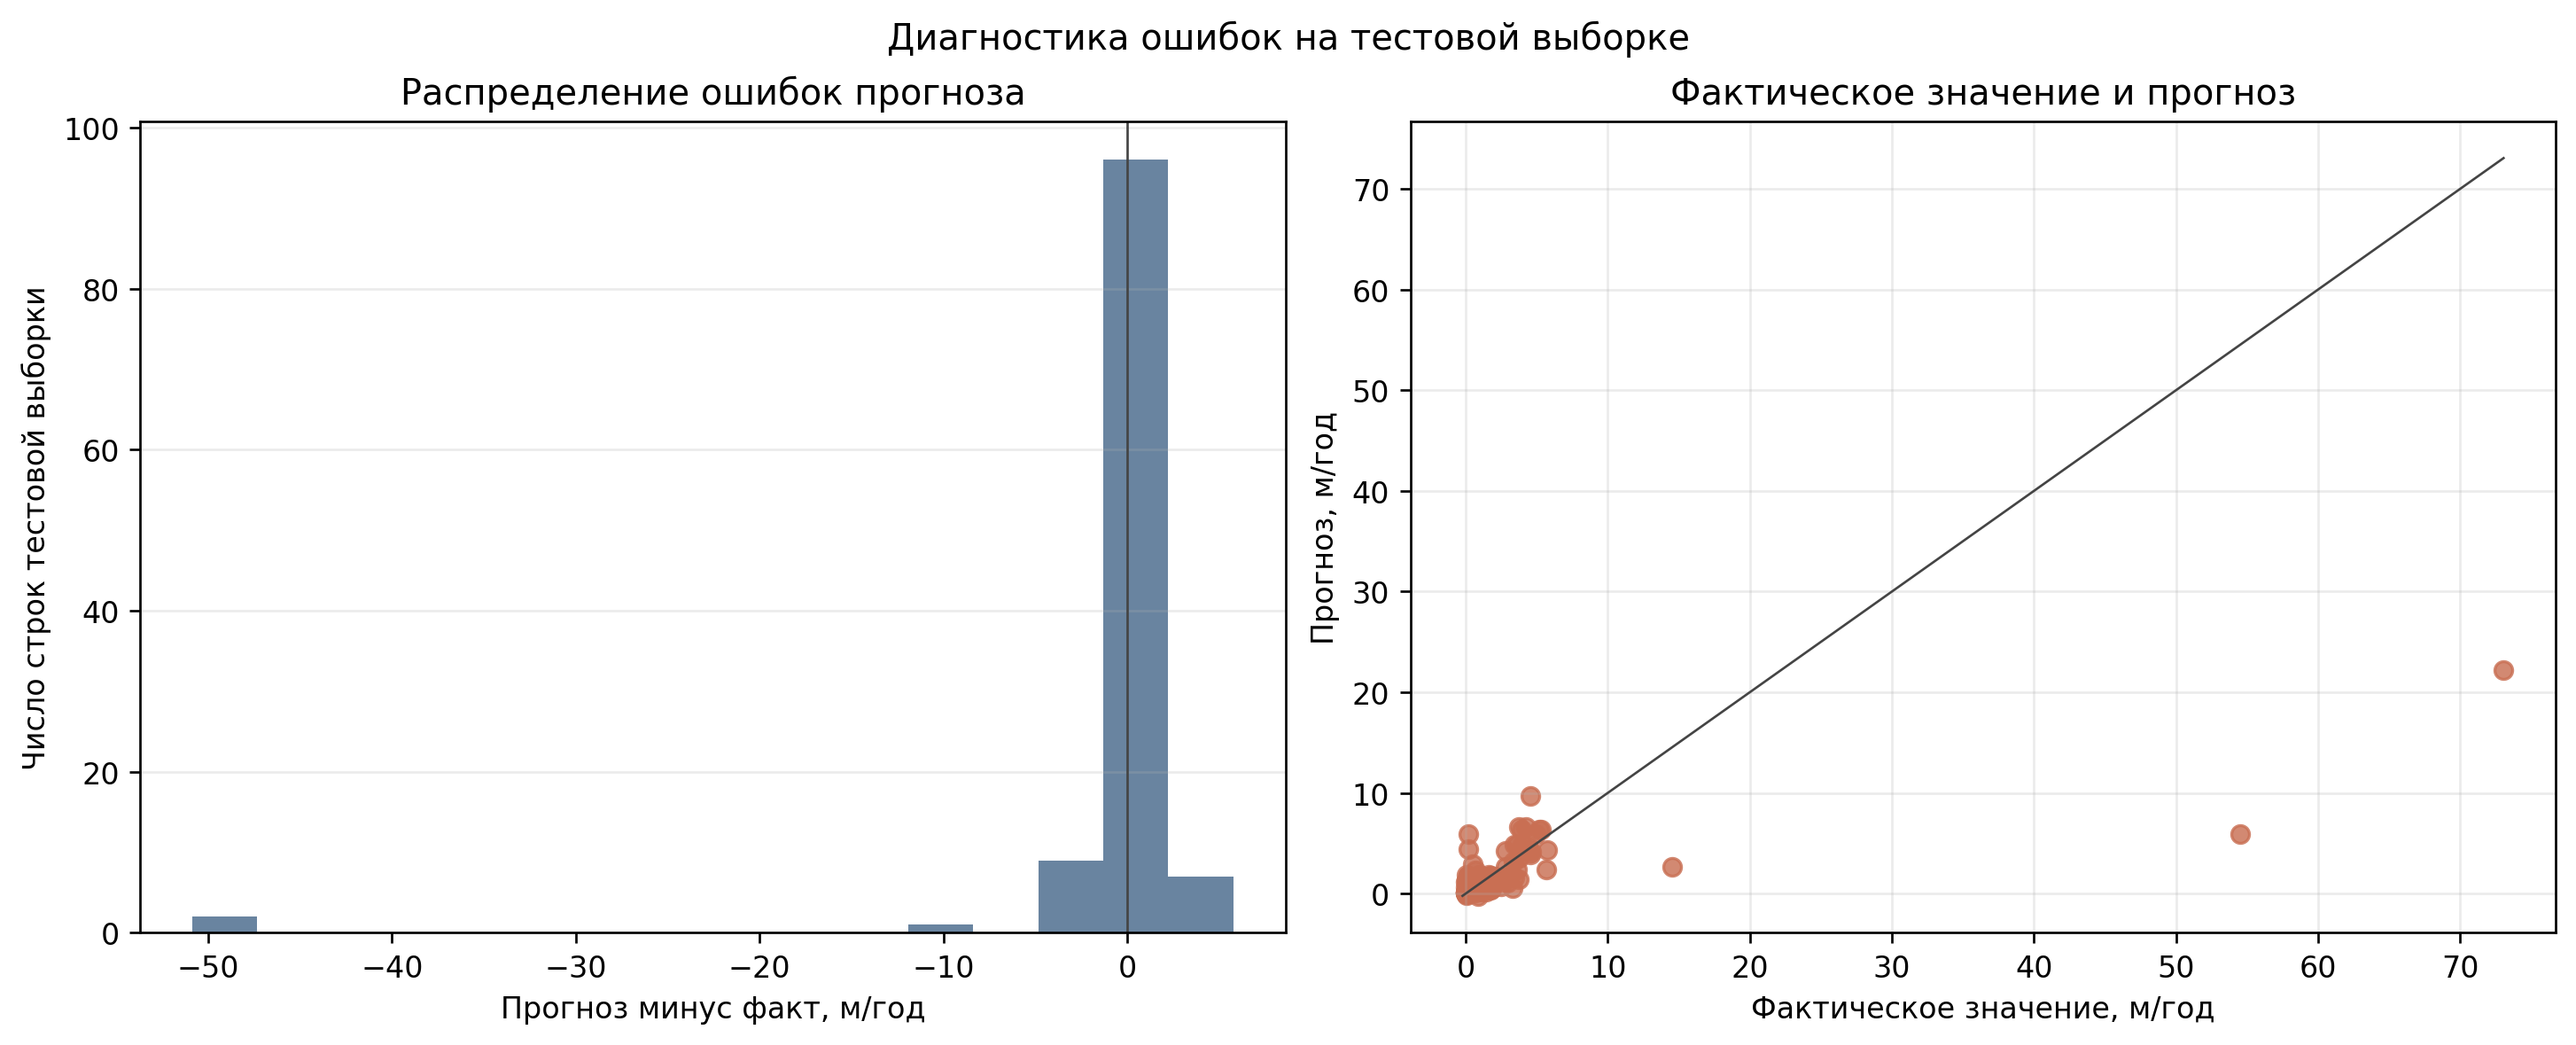

In [9]:
display(Image(filename=str(reports_dir / 'figures' / 'baseline_residuals.png')))

## Важность признаков

Для модели, лучшей по MAE на тестовой выборке при данном случайном разбиении, считается перестановочная важность признаков. Значение показывает, насколько растёт MAE, если перемешать один исходный признак.

Перестановочная важность показывает вклад признаков в текущей модели и текущей схеме проверки качества. Это не причинная интерпретация, и оценка может быть нестабильной при коррелированных признаках.

In [10]:
feature_importance.head(15)

,rank,target,model,feature_name,importance_mean,importance_std
0,1,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,interval_mid_year,0.700788,0.103355
1,2,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,exposure_sectors_text,0.269464,0.075822
2,3,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,history_start_year,0.191262,0.040647
3,4,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,shore_type,0.103340,0.032166
4,5,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,mean_water_level_mean_annual_m_abs,0.087677,0.014601
5,6,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,lithology_text,0.076744,0.037281
6,7,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,shore_orientation_text,0.065262,0.022143
7,8,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,n_water_obs,0.059375,0.025620
8,9,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,range_water_level_max_annual_m_abs,0.055641,0.031536
9,10,retreat_rate_abs_m_per_year,HistGradientBoostingRegressor,mean_water_level_max_annual_m_abs,0.054688,0.017676


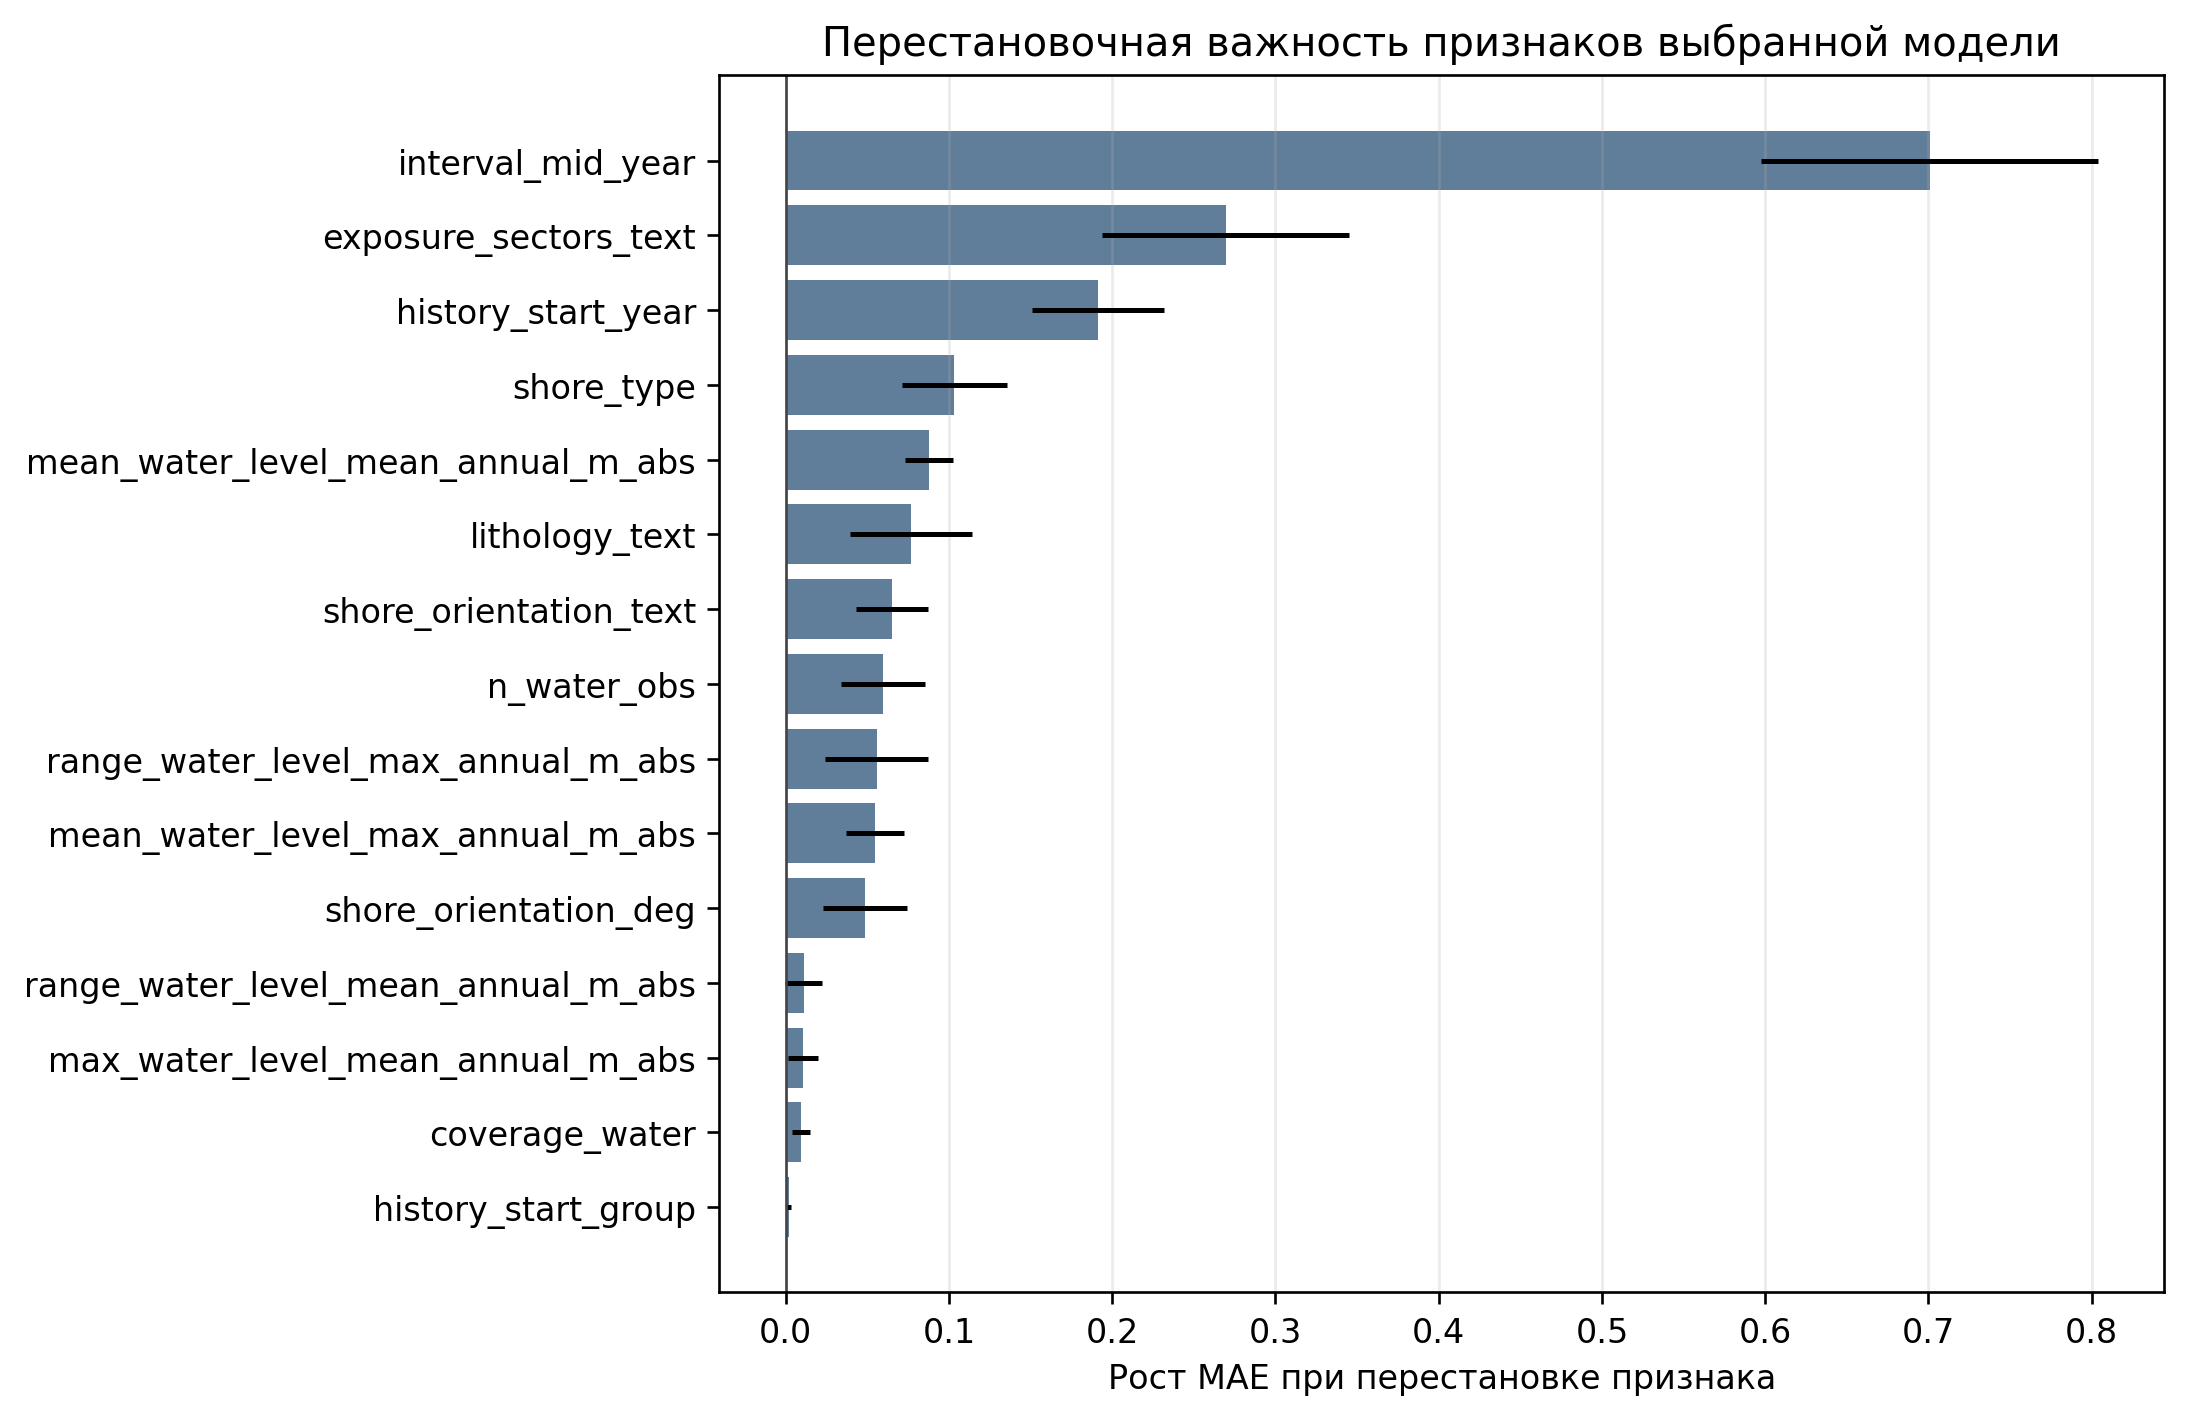

In [11]:
display(Image(filename=str(reports_dir / 'figures' / 'baseline_feature_importance.png')))

## Ограничения интерпретации

- Базовое моделирование не доказывает причинность и не заменяет предметную интерпретацию.
- Результаты зависят от качества, покрытия и структуры подготовленных данных.
- Кросс-валидация и групповая проверка могут давать другую картину, поэтому базовый эксперимент — это первичная оценка предсказательного сигнала.
- Ветер пока не используется как сильный объясняющий фактор, потому что покрытие на уровне интервалов остаётся ограничением.
- Вода трактуется как годовой контекст, а не как локальный датированный временной ряд по каждому участку.
- Конфликтующие дубли наблюдений береговой бровки не удаляются автоматически и требуют предметного решения.
- Знак смещения требует доменной интерпретации, поэтому в этом базовом эксперименте выбрана беззнаковая целевая переменная.

## Выводы и следующий этап

Базовый эксперимент показывает, насколько простые табличные модели и первый нейросетевой ориентир способны предсказывать беззнаковую интенсивность изменения береговой бровки по уже подготовленным признакам. При данном случайном разбиении одна модель может быть лучшей по MAE на тестовой выборке, но групповая проверка и кросс-валидация остаются обязательным контекстом для чтения результата.

Следующий этап НИР — аккуратно развить нейросетевую часть и сравнить её с классическими статистическими методами для задач поиска аномалий, сглаживания, восстановления пропусков и оценки качества моделей. `MLPRegressor` в этом ноутбуке — только первый сравнительный ориентир, а не финально настроенная нейросетевая модель.